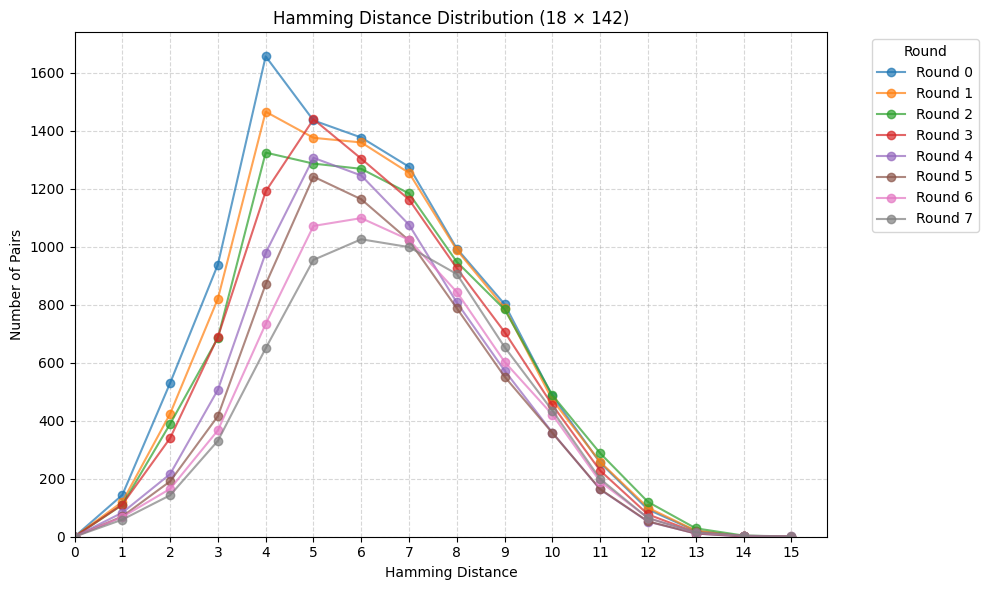

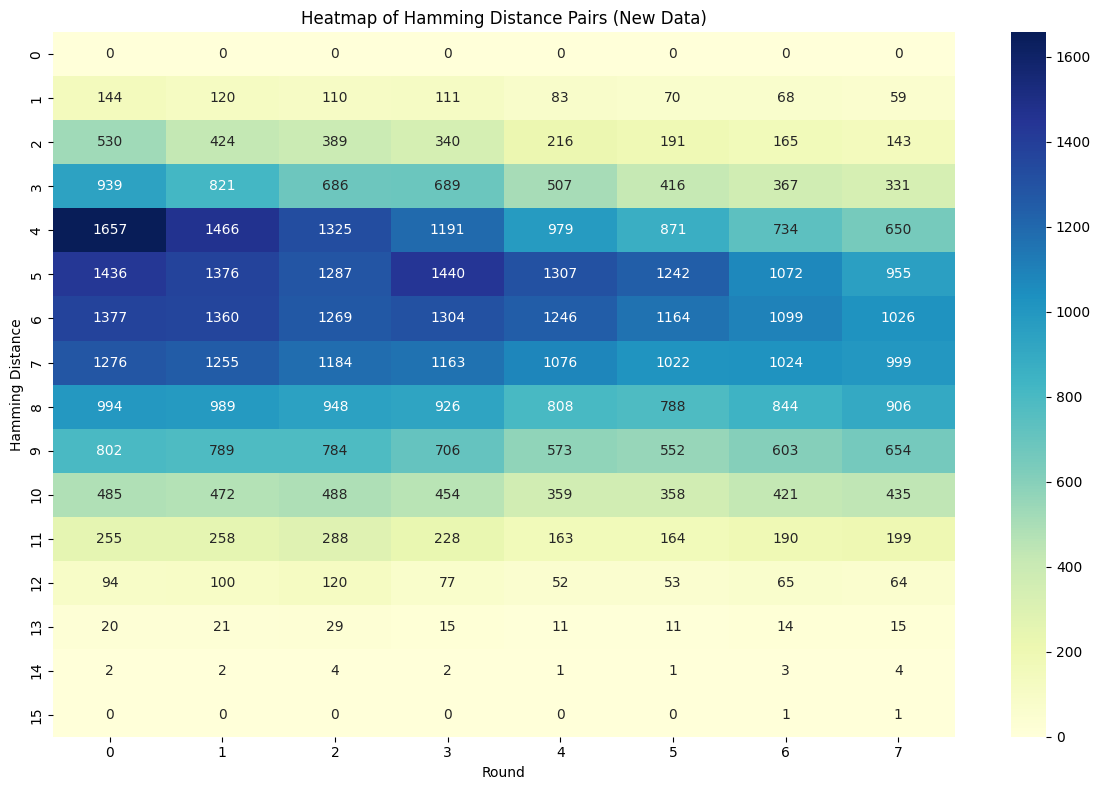

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re
import numpy as np

# 新しいログデータの入力
log_data = """
--- Testing Hamming Distance Version ---
in LempelX2_M4RI_Hamming
        Round = 0 (Start m: 142)
--- Hamming Distance Stats ---
 Dist 1: 144 pairs
 Dist 2: 530 pairs
 Dist 3: 939 pairs
 Dist 4: 1657 pairs
 Dist 5: 1436 pairs
 Dist 6: 1377 pairs
 Dist 7: 1276 pairs
 Dist 8: 994 pairs
 Dist 9: 802 pairs
 Dist 10: 485 pairs
 Dist 11: 255 pairs
 Dist 12: 94 pairs
 Dist 13: 20 pairs
 Dist 14: 2 pairs
-------------------------------
  [HIT!] Dist=1 | Deleted: 4 cols
>> Round 0 Result: Hit Rate = 100% (1/1)
        Round = 1 (Start m: 138)
--- Hamming Distance Stats ---
 Dist 1: 120 pairs
 Dist 2: 424 pairs
 Dist 3: 821 pairs
 Dist 4: 1466 pairs
 Dist 5: 1376 pairs
 Dist 6: 1360 pairs
 Dist 7: 1255 pairs
 Dist 8: 989 pairs
 Dist 9: 789 pairs
 Dist 10: 472 pairs
 Dist 11: 258 pairs
 Dist 12: 100 pairs
 Dist 13: 21 pairs
 Dist 14: 2 pairs
-------------------------------
  [HIT!] Dist=1 | Deleted: 4 cols
>> Round 1 Result: Hit Rate = 33.3333% (1/3)
        Round = 2 (Start m: 134)
--- Hamming Distance Stats ---
 Dist 1: 110 pairs
 Dist 2: 389 pairs
 Dist 3: 686 pairs
 Dist 4: 1325 pairs
 Dist 5: 1287 pairs
 Dist 6: 1269 pairs
 Dist 7: 1184 pairs
 Dist 8: 948 pairs
 Dist 9: 784 pairs
 Dist 10: 488 pairs
 Dist 11: 288 pairs
 Dist 12: 120 pairs
 Dist 13: 29 pairs
 Dist 14: 4 pairs
-------------------------------
  [HIT!] Dist=1 | Deleted: 2 cols
>> Round 2 Result: Hit Rate = 100% (1/1)
        Round = 3 (Start m: 132)
--- Hamming Distance Stats ---
 Dist 1: 111 pairs
 Dist 2: 340 pairs
 Dist 3: 689 pairs
 Dist 4: 1191 pairs
 Dist 5: 1440 pairs
 Dist 6: 1304 pairs
 Dist 7: 1163 pairs
 Dist 8: 926 pairs
 Dist 9: 706 pairs
 Dist 10: 454 pairs
 Dist 11: 228 pairs
 Dist 12: 77 pairs
 Dist 13: 15 pairs
 Dist 14: 2 pairs
-------------------------------
  [HIT!] Dist=1 | Deleted: 10 cols
>> Round 3 Result: Hit Rate = 100% (1/1)
        Round = 4 (Start m: 122)
--- Hamming Distance Stats ---
 Dist 1: 83 pairs
 Dist 2: 216 pairs
 Dist 3: 507 pairs
 Dist 4: 979 pairs
 Dist 5: 1307 pairs
 Dist 6: 1246 pairs
 Dist 7: 1076 pairs
 Dist 8: 808 pairs
 Dist 9: 573 pairs
 Dist 10: 359 pairs
 Dist 11: 163 pairs
 Dist 12: 52 pairs
 Dist 13: 11 pairs
 Dist 14: 1 pairs
-------------------------------
  [HIT!] Dist=1 | Deleted: 4 cols
>> Round 4 Result: Hit Rate = 16.6667% (1/6)
        Round = 5 (Start m: 118)
--- Hamming Distance Stats ---
 Dist 1: 70 pairs
 Dist 2: 191 pairs
 Dist 3: 416 pairs
 Dist 4: 871 pairs
 Dist 5: 1242 pairs
 Dist 6: 1164 pairs
 Dist 7: 1022 pairs
 Dist 8: 788 pairs
 Dist 9: 552 pairs
 Dist 10: 358 pairs
 Dist 11: 164 pairs
 Dist 12: 53 pairs
 Dist 13: 11 pairs
 Dist 14: 1 pairs
-------------------------------
  [HIT!] Dist=3 | Deleted: 2 cols
>> Round 5 Result: Hit Rate = 0.378788% (1/264)
        Round = 6 (Start m: 116)
--- Hamming Distance Stats ---
 Dist 1: 68 pairs
 Dist 2: 165 pairs
 Dist 3: 367 pairs
 Dist 4: 734 pairs
 Dist 5: 1072 pairs
 Dist 6: 1099 pairs
 Dist 7: 1024 pairs
 Dist 8: 844 pairs
 Dist 9: 603 pairs
 Dist 10: 421 pairs
 Dist 11: 190 pairs
 Dist 12: 65 pairs
 Dist 13: 14 pairs
 Dist 14: 3 pairs
 Dist 15: 1 pairs
-------------------------------
  [HIT!] Dist=5 | Deleted: 2 cols
>> Round 6 Result: Hit Rate = 0.0472144% (1/2118)
        Round = 7 (Start m: 114)
--- Hamming Distance Stats ---
 Dist 1: 59 pairs
 Dist 2: 143 pairs
 Dist 3: 331 pairs
 Dist 4: 650 pairs
 Dist 5: 955 pairs
 Dist 6: 1026 pairs
 Dist 7: 999 pairs
 Dist 8: 906 pairs
 Dist 9: 654 pairs
 Dist 10: 435 pairs
 Dist 11: 199 pairs
 Dist 12: 64 pairs
 Dist 13: 15 pairs
 Dist 14: 4 pairs
 Dist 15: 1 pairs
-------------------------------
"""

# データの抽出
data = []
current_round = None

lines = log_data.split('\n')
for line in lines:
    round_match = re.search(r'Round = (\d+)', line)
    if round_match:
        current_round = int(round_match.group(1))
    
    dist_match = re.search(r'Dist (\d+): (\d+) pairs', line)
    if dist_match and current_round is not None:
        dist = int(dist_match.group(1))
        pairs = int(dist_match.group(2))
        data.append({'Round': current_round, 'Distance': dist, 'Pairs': pairs})

df = pd.DataFrame(data)

# ピボットテーブル作成
pivot_df = df.pivot(index='Distance', columns='Round', values='Pairs').fillna(0)

# 軸の整合性（0から最大距離まで）
max_dist = int(pivot_df.index.max())
full_index = range(0, max_dist + 1)
pivot_df = pivot_df.reindex(full_index).fillna(0)

# 1. ハミング距離分布図 (折れ線グラフ)
plt.figure(figsize=(10, 6))
for r in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[r], label=f'Round {r}', marker='o', alpha=0.7)

plt.title('Hamming Distance Distribution (18 × 142)')
plt.xlabel('Hamming Distance')
plt.ylabel('Number of Pairs')

# 軸設定: 整数のみ、0から開始
plt.xticks(full_index)
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.legend(title='Round', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. ヒートマップ
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap of Hamming Distance Pairs (New Data)')
plt.xlabel('Round')
plt.ylabel('Hamming Distance')
plt.tight_layout()
plt.show()

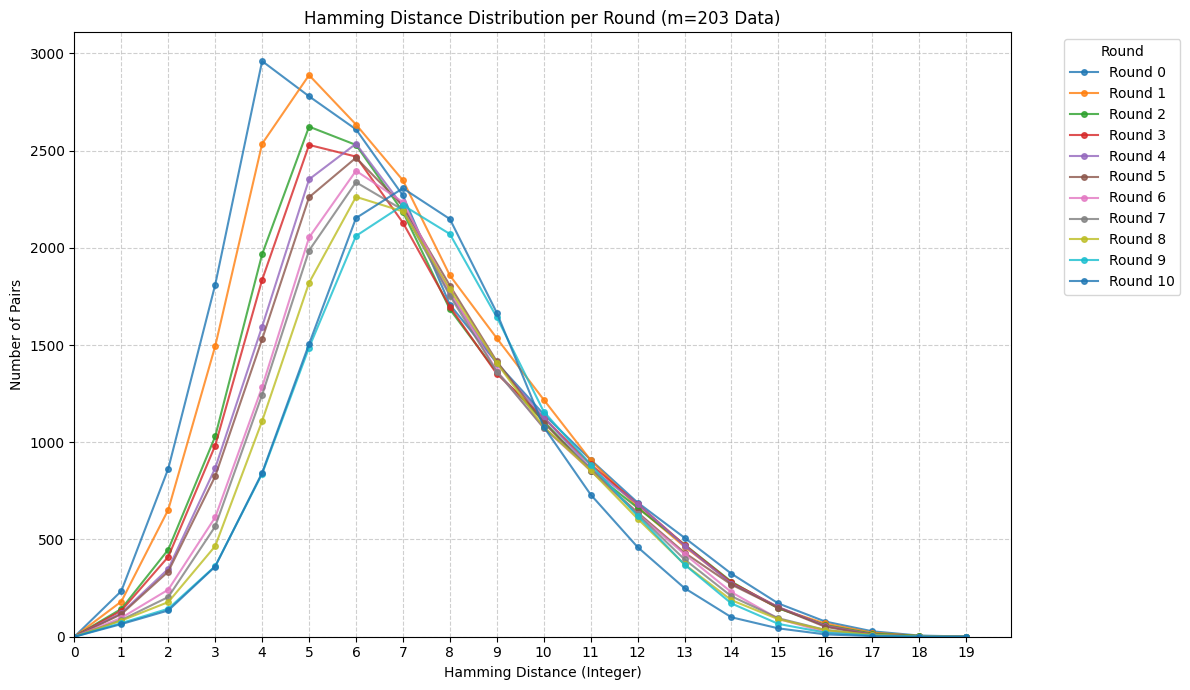

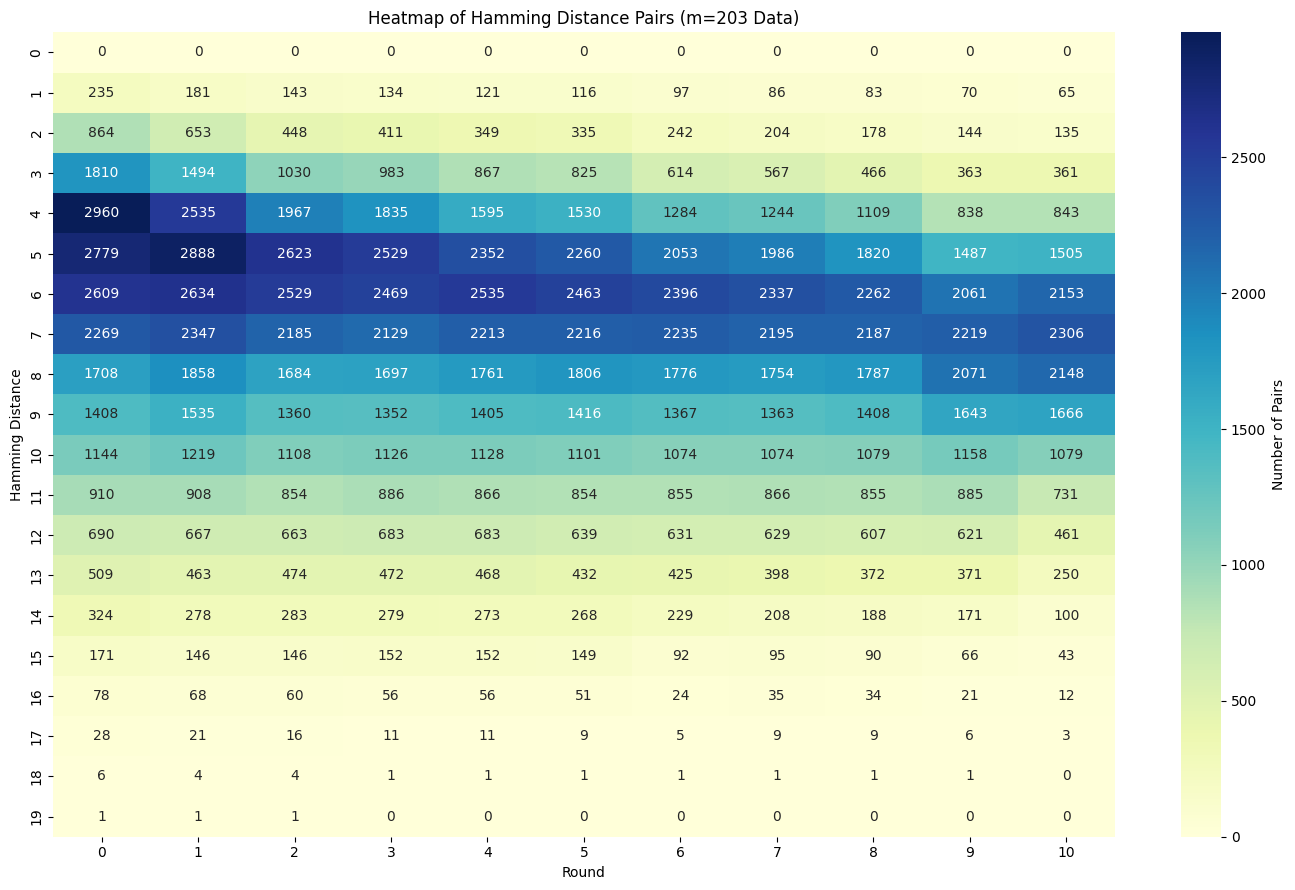

CSV saved as 'hamming_stats_m203.csv'


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re
import numpy as np

# 1. ログデータの定義
log_data = """
 --- Testing Hamming Distance Version --- 
 in LempelX2_M4RI_Hamming 
         Round = 0 (Start m: 203) 
 --- Hamming Distance Stats --- 
  Dist 1: 235 pairs 
  Dist 2: 864 pairs 
  Dist 3: 1810 pairs 
  Dist 4: 2960 pairs 
  Dist 5: 2779 pairs 
  Dist 6: 2609 pairs 
  Dist 7: 2269 pairs 
  Dist 8: 1708 pairs 
  Dist 9: 1408 pairs 
  Dist 10: 1144 pairs 
  Dist 11: 910 pairs 
  Dist 12: 690 pairs 
  Dist 13: 509 pairs 
  Dist 14: 324 pairs 
  Dist 15: 171 pairs 
  Dist 16: 78 pairs 
  Dist 17: 28 pairs 
  Dist 18: 6 pairs 
  Dist 19: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=1 | Deleted: 3 cols 
 >> Round 0 Result: Hit Rate = 100% (1/1) 
         Round = 1 (Start m: 200) 
 --- Hamming Distance Stats --- 
  Dist 1: 181 pairs 
  Dist 2: 653 pairs 
  Dist 3: 1494 pairs 
  Dist 4: 2535 pairs 
  Dist 5: 2888 pairs 
  Dist 6: 2634 pairs 
  Dist 7: 2347 pairs 
  Dist 8: 1858 pairs 
  Dist 9: 1535 pairs 
  Dist 10: 1219 pairs 
  Dist 11: 908 pairs 
  Dist 12: 667 pairs 
  Dist 13: 463 pairs 
  Dist 14: 278 pairs 
  Dist 15: 146 pairs 
  Dist 16: 68 pairs 
  Dist 17: 21 pairs 
  Dist 18: 4 pairs 
  Dist 19: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=1 | Deleted: 12 cols 
 >> Round 1 Result: Hit Rate = 100% (1/1) 
         Round = 2 (Start m: 188) 
 --- Hamming Distance Stats --- 
  Dist 1: 143 pairs 
  Dist 2: 448 pairs 
  Dist 3: 1030 pairs 
  Dist 4: 1967 pairs 
  Dist 5: 2623 pairs 
  Dist 6: 2529 pairs 
  Dist 7: 2185 pairs 
  Dist 8: 1684 pairs 
  Dist 9: 1360 pairs 
  Dist 10: 1108 pairs 
  Dist 11: 854 pairs 
  Dist 12: 663 pairs 
  Dist 13: 474 pairs 
  Dist 14: 283 pairs 
  Dist 15: 146 pairs 
  Dist 16: 60 pairs 
  Dist 17: 16 pairs 
  Dist 18: 4 pairs 
  Dist 19: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=1 | Deleted: 2 cols 
 >> Round 2 Result: Hit Rate = 20% (1/5) 
         Round = 3 (Start m: 186) 
 --- Hamming Distance Stats --- 
  Dist 1: 134 pairs 
  Dist 2: 411 pairs 
  Dist 3: 983 pairs 
  Dist 4: 1835 pairs 
  Dist 5: 2529 pairs 
  Dist 6: 2469 pairs 
  Dist 7: 2129 pairs 
  Dist 8: 1697 pairs 
  Dist 9: 1352 pairs 
  Dist 10: 1126 pairs 
  Dist 11: 886 pairs 
  Dist 12: 683 pairs 
  Dist 13: 472 pairs 
  Dist 14: 279 pairs 
  Dist 15: 152 pairs 
  Dist 16: 56 pairs 
  Dist 17: 11 pairs 
  Dist 18: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=1 | Deleted: 2 cols 
 >> Round 3 Result: Hit Rate = 100% (1/1) 
         Round = 4 (Start m: 184) 
 --- Hamming Distance Stats --- 
  Dist 1: 121 pairs 
  Dist 2: 349 pairs 
  Dist 3: 867 pairs 
  Dist 4: 1595 pairs 
  Dist 5: 2352 pairs 
  Dist 6: 2535 pairs 
  Dist 7: 2213 pairs 
  Dist 8: 1761 pairs 
  Dist 9: 1405 pairs 
  Dist 10: 1128 pairs 
  Dist 11: 866 pairs 
  Dist 12: 683 pairs 
  Dist 13: 468 pairs 
  Dist 14: 273 pairs 
  Dist 15: 152 pairs 
  Dist 16: 56 pairs 
  Dist 17: 11 pairs 
  Dist 18: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=1 | Deleted: 2 cols 
 >> Round 4 Result: Hit Rate = 100% (1/1) 
         Round = 5 (Start m: 182) 
 --- Hamming Distance Stats --- 
  Dist 1: 116 pairs 
  Dist 2: 335 pairs 
  Dist 3: 825 pairs 
  Dist 4: 1530 pairs 
  Dist 5: 2260 pairs 
  Dist 6: 2463 pairs 
  Dist 7: 2216 pairs 
  Dist 8: 1806 pairs 
  Dist 9: 1416 pairs 
  Dist 10: 1101 pairs 
  Dist 11: 854 pairs 
  Dist 12: 639 pairs 
  Dist 13: 432 pairs 
  Dist 14: 268 pairs 
  Dist 15: 149 pairs 
  Dist 16: 51 pairs 
  Dist 17: 9 pairs 
  Dist 18: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=1 | Deleted: 6 cols 
 >> Round 5 Result: Hit Rate = 9.09091% (1/11) 
         Round = 6 (Start m: 176) 
 --- Hamming Distance Stats --- 
  Dist 1: 97 pairs 
  Dist 2: 242 pairs 
  Dist 3: 614 pairs 
  Dist 4: 1284 pairs 
  Dist 5: 2053 pairs 
  Dist 6: 2396 pairs 
  Dist 7: 2235 pairs 
  Dist 8: 1776 pairs 
  Dist 9: 1367 pairs 
  Dist 10: 1074 pairs 
  Dist 11: 855 pairs 
  Dist 12: 631 pairs 
  Dist 13: 425 pairs 
  Dist 14: 229 pairs 
  Dist 15: 92 pairs 
  Dist 16: 24 pairs 
  Dist 17: 5 pairs 
  Dist 18: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=2 | Deleted: 2 cols 
 >> Round 6 Result: Hit Rate = 0.78125% (1/128) 
         Round = 7 (Start m: 174) 
 --- Hamming Distance Stats --- 
  Dist 1: 86 pairs 
  Dist 2: 204 pairs 
  Dist 3: 567 pairs 
  Dist 4: 1244 pairs 
  Dist 5: 1986 pairs 
  Dist 6: 2337 pairs 
  Dist 7: 2195 pairs 
  Dist 8: 1754 pairs 
  Dist 9: 1363 pairs 
  Dist 10: 1074 pairs 
  Dist 11: 866 pairs 
  Dist 12: 629 pairs 
  Dist 13: 398 pairs 
  Dist 14: 208 pairs 
  Dist 15: 95 pairs 
  Dist 16: 35 pairs 
  Dist 17: 9 pairs 
  Dist 18: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=3 | Deleted: 3 cols 
 >> Round 7 Result: Hit Rate = 0.141044% (1/709) 
         Round = 8 (Start m: 171) 
 --- Hamming Distance Stats --- 
  Dist 1: 83 pairs 
  Dist 2: 178 pairs 
  Dist 3: 466 pairs 
  Dist 4: 1109 pairs 
  Dist 5: 1820 pairs 
  Dist 6: 2262 pairs 
  Dist 7: 2187 pairs 
  Dist 8: 1787 pairs 
  Dist 9: 1408 pairs 
  Dist 10: 1079 pairs 
  Dist 11: 855 pairs 
  Dist 12: 607 pairs 
  Dist 13: 372 pairs 
  Dist 14: 188 pairs 
  Dist 15: 90 pairs 
  Dist 16: 34 pairs 
  Dist 17: 9 pairs 
  Dist 18: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=6 | Deleted: 2 cols 
 >> Round 8 Result: Hit Rate = 0.019604% (1/5101) 
         Round = 9 (Start m: 169) 
 --- Hamming Distance Stats --- 
  Dist 1: 70 pairs 
  Dist 2: 144 pairs 
  Dist 3: 363 pairs 
  Dist 4: 838 pairs 
  Dist 5: 1487 pairs 
  Dist 6: 2061 pairs 
  Dist 7: 2219 pairs 
  Dist 8: 2071 pairs 
  Dist 9: 1643 pairs 
  Dist 10: 1158 pairs 
  Dist 11: 885 pairs 
  Dist 12: 621 pairs 
  Dist 13: 371 pairs 
  Dist 14: 171 pairs 
  Dist 15: 66 pairs 
  Dist 16: 21 pairs 
  Dist 17: 6 pairs 
  Dist 18: 1 pairs 
 ------------------------------- 
  [HIT!] Dist=8 | Deleted: 2 cols 
 >> Round 9 Result: Hit Rate = 0.0113084% (1/8843) 
         Round = 10 (Start m: 167) 
 --- Hamming Distance Stats --- 
  Dist 1: 65 pairs 
  Dist 2: 135 pairs 
  Dist 3: 361 pairs 
  Dist 4: 843 pairs 
  Dist 5: 1505 pairs 
  Dist 6: 2153 pairs 
  Dist 7: 2306 pairs 
  Dist 8: 2148 pairs 
  Dist 9: 1666 pairs 
  Dist 10: 1079 pairs 
  Dist 11: 731 pairs 
  Dist 12: 461 pairs 
  Dist 13: 250 pairs 
  Dist 14: 100 pairs 
  Dist 15: 43 pairs 
  Dist 16: 12 pairs 
  Dist 17: 3 pairs 
 ------------------------------- 
"""

# 2. データのパース (Round, Distance, Pairsを抽出)
data = []
current_round = None

lines = log_data.strip().split('\n')
for line in lines:
    round_match = re.search(r'Round\s*=\s*(\d+)', line)
    if round_match:
        current_round = int(round_match.group(1))
    
    dist_match = re.search(r'Dist\s*(\d+):\s*(\d+)\s*pairs', line)
    if dist_match and current_round is not None:
        dist = int(dist_match.group(1))
        pairs = int(dist_match.group(2))
        data.append({'Round': current_round, 'Distance': dist, 'Pairs': pairs})

df = pd.DataFrame(data)

# 3. グラフ描画用のピボットテーブル作成
pivot_df = df.pivot(index='Distance', columns='Round', values='Pairs').fillna(0)

# 距離0から最大値までをインデックス化して軸を補正
max_dist = int(pivot_df.index.max())
full_dist_range = range(0, max_dist + 1)
pivot_df = pivot_df.reindex(full_dist_range).fillna(0)

# --- 描画 1: 折れ線グラフ ---
plt.figure(figsize=(12, 7))
for r in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[r], label=f'Round {r}', marker='o', markersize=4, alpha=0.8)

plt.title('Hamming Distance Distribution per Round (21 × 203)')
plt.xlabel('Hamming Distance (Integer)')
plt.ylabel('Number of Pairs')

# 横軸を整数のみに設定し、0から開始
plt.xticks(full_dist_range)
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.legend(title='Round', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 描画 2: ヒートマップ ---
plt.figure(figsize=(14, 9))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Number of Pairs'})
plt.title('Heatmap of Hamming Distance Pairs (m=203 Data)')
plt.xlabel('Round')
plt.ylabel('Hamming Distance')
plt.tight_layout()
plt.show()

# CSVとして保存
pivot_df.to_csv('hamming_stats_m203.csv')
print("CSV saved as 'hamming_stats_m203.csv'")